In [1]:
# Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import roc_auc_score
from einops import rearrange
from tqdm import tqdm
from torchmetrics.functional import structural_similarity_index_measure
import torch.nn.functional as F

# Dataset Class
class MVTecLOCODataset(Dataset):
    def __init__(self, root_dir, split='train', anomaly_type='logical_anomalies', transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []  # 0 for normal, 1 for anomaly

        if split == 'train':
            # Load 'good' images for training
            good_dir = os.path.join(root_dir, 'train', 'good')
            self._load_images_from_folder(good_dir, label=0)
        elif split == 'test':
            # Load 'good' and specified anomalies for testing
            good_dir = os.path.join(root_dir, 'test', 'good')
            anomaly_dir = os.path.join(root_dir, 'test', anomaly_type)
            self._load_images_from_folder(good_dir, label=0)
            self._load_images_from_folder(anomaly_dir, label=1)
        else:
            raise ValueError(f"Invalid split: {split}")

    def _load_images_from_folder(self, folder, label):
        if not os.path.isdir(folder):
            print(f"Folder {folder} is missing!")
            return
        for root, _, files in os.walk(folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, file)
                    self.image_paths.append(img_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label, img_path

In [2]:
# H_TAE Model Components
class TruncatedDense(nn.Module):
    def __init__(self, in_features, out_features, use_bias=True):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=use_bias)
        nn.init.trunc_normal_(self.linear.weight, mean=0.0, std=0.02)
        if use_bias:
            nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        return self.linear(x)

In [3]:
class PatchMerging(nn.Module):
    def __init__(self, input_resolution, dim):
        super().__init__()
        self.input_resolution = input_resolution
        self.dim = dim  # refer to the projection_dim (nC)
        self.reduction = TruncatedDense(4 * dim, 2 * dim, use_bias=False)
        self.norm = nn.LayerNorm(4 * dim, eps=1e-5)

    def forward(self, x):
        """
        x: B, H*W, C
        """
        H = W = self.input_resolution
        B = x.shape[0]

        x = x.view(B, H, W, self.dim)
        x0 = x[:, 0::2, 0::2, :]  # B, H/2, W/2, C
        x1 = x[:, 1::2, 0::2, :]  # B, H/2, W/2, C
        x2 = x[:, 0::2, 1::2, :]  # B, H/2, W/2, C
        x3 = x[:, 1::2, 1::2, :]  # B, H/2, W/2, C

        x = torch.cat([x0, x1, x2, x3], dim=-1)  # B, H/2, W/2, 4*C
        x = x.view(B, -1, 4 * self.dim)  # B, H/2*W/2, 4*C
        x = self.norm(x)
        x = self.reduction(x)

        return x

In [4]:
class PatchExpanding(nn.Module):
    def __init__(self, input_resolution, dim):
        super().__init__()
        self.input_resolution = input_resolution
        self.dim = dim  # Keep embedding dimension constant
        self.expand = TruncatedDense(dim, dim * 4, use_bias=False)
        self.norm = nn.LayerNorm(dim, eps=1e-5)

    def forward(self, x):
        H = W = self.input_resolution
        B = x.shape[0]

        x = self.expand(x)  # Shape: B, H*W, 4*dim
        x = x.view(B, H, W, 4 * self.dim)  # Shape: B, H, W, 4*dim

        x = rearrange(
            x,
            'b h w (p1 p2 c) -> b (h p1) (w p2) c',
            p1=2,
            p2=2,
            c=self.dim
        )
        x = x.view(B, (H * 2) * (W * 2), self.dim)
        x = self.norm(x)

        return x

In [5]:
class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = TruncatedDense(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = TruncatedDense(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class EncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, rate):
        super().__init__()
        self.num_heads = num_heads
        self.rate = rate
        self.embed_dim = embed_dim

        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=rate)
        self.dropout1 = nn.Dropout(rate)
        self.norm1 = nn.LayerNorm(embed_dim, eps=1e-6)

        self.mlp = Mlp(embed_dim, hidden_features=4 * embed_dim, drop=rate)
        self.norm2 = nn.LayerNorm(embed_dim, eps=1e-6)

    def forward(self, x):
        # x shape: (B, N, C)
        x_ = x.permute(1, 0, 2)  # (N, B, C)
        attn_output, _ = self.attn(x_, x_, x_)
        attn_output = self.dropout1(attn_output)
        x = x + attn_output.permute(1, 0, 2)
        x = self.norm1(x)

        x_mlp = self.mlp(x)
        x = x + x_mlp
        x = self.norm2(x)
        return x

class DecoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, rate):
        super().__init__()
        self.num_heads = num_heads
        self.rate = rate
        self.embed_dim = embed_dim

        self.attn1 = nn.MultiheadAttention(embed_dim, num_heads, dropout=rate)
        self.dropout1 = nn.Dropout(rate)
        self.norm1 = nn.LayerNorm(embed_dim, eps=1e-6)

        self.attn2 = nn.MultiheadAttention(embed_dim, num_heads, dropout=rate)
        self.dropout2 = nn.Dropout(rate)
        self.norm2 = nn.LayerNorm(embed_dim, eps=1e-6)

        self.mlp = Mlp(embed_dim, hidden_features=4 * embed_dim, drop=rate)
        self.norm3 = nn.LayerNorm(embed_dim, eps=1e-6)

    def forward(self, target, memory):
        # target and memory shape: (B, N, C)
        tgt = target.permute(1, 0, 2)  # (N, B, C)
        memory = memory.permute(1, 0, 2)

        attn_output1, _ = self.attn1(tgt, tgt, tgt)
        attn_output1 = self.dropout1(attn_output1)
        target = target + attn_output1.permute(1, 0, 2)
        target = self.norm1(target)

        attn_output2, _ = self.attn2(target.permute(1, 0, 2), memory, memory)
        attn_output2 = self.dropout2(attn_output2)
        target = target + attn_output2.permute(1, 0, 2)
        target = self.norm2(target)

        x_mlp = self.mlp(target)
        target = target + x_mlp
        target = self.norm3(target)

        return target

In [6]:
class TransformerAutoencoder(nn.Module):
    def __init__(self, transformer_layers, num_heads, rate, input_resolution, embed_dim):
        super().__init__()
        self.transformer_layers = transformer_layers
        self.num_heads = num_heads
        self.rate = rate
        self.input_resolution = input_resolution
        self.embed_dim = embed_dim

        self.encoder_layers = nn.ModuleList()
        self.decoder_layers = nn.ModuleList()
        curr_input_resolution = input_resolution
        curr_embed_dim = embed_dim

        # Build encoder layers
        for iter1 in range(transformer_layers // 2):
            layers = nn.ModuleList()
            if iter1 != 0:
                layers.append(PatchMerging(curr_input_resolution, curr_embed_dim))
                curr_input_resolution = curr_input_resolution // 2
                curr_embed_dim = curr_embed_dim * 2
            layers.append(EncoderLayer(curr_embed_dim, num_heads, rate))
            layers.append(EncoderLayer(curr_embed_dim, num_heads, rate))
            self.encoder_layers.append(layers)

        # Build decoder layers
        for iter2 in range(transformer_layers // 2):
            layers = nn.ModuleList()
            if iter2 != 0:
                layers.append(PatchExpanding(curr_input_resolution, curr_embed_dim))
                curr_input_resolution = curr_input_resolution * 2
                # Do not update curr_embed_dim
            layers.append(DecoderLayer(curr_embed_dim, num_heads, rate))
            layers.append(DecoderLayer(curr_embed_dim, num_heads, rate))
            self.decoder_layers.append(layers)

    def forward(self, x):
        # x: B, N, C
        memory = x
        curr_input_resolution = self.input_resolution
        curr_embed_dim = self.embed_dim

        # Encoder
        for layers in self.encoder_layers:
            for layer in layers:
                if isinstance(layer, PatchMerging):
                    x = layer(x)
                    curr_input_resolution = curr_input_resolution // 2
                    curr_embed_dim = curr_embed_dim * 2
                else:
                    x = layer(x)

        # x is the output from the encoder
        encoded_patches = x

        # Decoder
        x = encoded_patches
        for layers in self.decoder_layers:
            for layer in layers:
                if isinstance(layer, PatchExpanding):
                    x = layer(x)
                    curr_input_resolution = curr_input_resolution * 2
                    # Do not update curr_embed_dim
                elif isinstance(layer, DecoderLayer):
                    x = layer(x, encoded_patches)
                else:
                    x = layer(x)
        return x

In [8]:
class TAE(nn.Module):
    def __init__(self, image_size, patch_size, num_channels, filters, transformer_layers, num_heads, rate):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_channels = num_channels
        self.filters = filters  # Initial embedding dimension
        self.transformer_layers = transformer_layers
        self.num_heads = num_heads
        self.rate = rate

        self.input_resolution = image_size // patch_size  # 1024 // 32 = 32
        self.embed_dim = filters

        # Layers
        self.conv = nn.Conv2d(num_channels, filters, kernel_size=patch_size, stride=patch_size)
        self.layer_norm = nn.LayerNorm(filters, eps=1e-5)

        self.transformer_autoencoder = TransformerAutoencoder(
            transformer_layers=self.transformer_layers,
            num_heads=self.num_heads,
            rate=self.rate,
            input_resolution=self.input_resolution,
            embed_dim=self.embed_dim
        )

        # Calculate the embedding dimension after the encoder
        num_downsampling = (self.transformer_layers // 2) - 1  # 3
        self.curr_embed_dim = self.filters * (2 ** num_downsampling)  # 256 * 8 = 2048
        self.output_resolution = self.input_resolution  # Should remain 32

        # Upsampling layers using ConvTranspose2d
        upsample_layers = []
        curr_filters = self.curr_embed_dim  # Starts at 2048
        curr_resolution = self.output_resolution  # Starts at 32

        while curr_resolution < self.image_size:
            upsample_layers.append(nn.ConvTranspose2d(curr_filters, curr_filters // 2, kernel_size=4, stride=2, padding=1))
            upsample_layers.append(nn.BatchNorm2d(curr_filters // 2))
            upsample_layers.append(nn.ReLU(inplace=True))
            curr_filters = curr_filters // 2
            curr_resolution *= 2

        # Final convolution to get back to num_channels
        upsample_layers.append(nn.Conv2d(curr_filters, self.num_channels, kernel_size=3, padding=1))
        self.upsample = nn.Sequential(*upsample_layers)

    def forward(self, x):
        B = x.size(0)
        # x: (B, num_channels, image_size, image_size)
        projection = self.conv(x)  # Shape: (B, filters, H', W') => (B, 256, 32, 32)
        projection = projection.permute(0, 2, 3, 1)  # Shape: (B, H', W', filters)
        projection = self.layer_norm(projection)
        enc_patches = projection.view(B, -1, self.filters)  # Shape: (B, H'*W', filters)

        decoded_patches = self.transformer_autoencoder(enc_patches)

        # Reshape back to image dimensions using curr_embed_dim and output_resolution
        decoded_patches = decoded_patches.view(B, self.output_resolution, self.output_resolution, self.curr_embed_dim)
        decoded_patches = decoded_patches.permute(0, 3, 1, 2)  # Shape: (B, curr_embed_dim, H'', W'')

        # Upsample to original size
        reconstructed = self.upsample(decoded_patches)  # Shape: (B, num_channels, image_size, image_size)

        return reconstructed


In [9]:
# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()
    anomaly_scores = []
    labels = []
    with torch.no_grad():
        for images, label, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            # Compute per-pixel reconstruction error
            recon_error = ((outputs - images) ** 2).mean(dim=[1,2,3])  # Mean over H,W,C
            anomaly_scores.extend(recon_error.cpu().numpy())
            labels.extend(label.cpu().numpy())
    # Compute AUROC
    auroc = roc_auc_score(labels, anomaly_scores)
    return auroc

# Visualization Function
def visualize_reconstruction(model, dataloader, device):
    model.eval()
    images, labels, paths = next(iter(dataloader))
    images = images.to(device)
    with torch.no_grad():
        reconstructed = model(images)
    images = images.cpu().numpy().transpose(0, 2, 3, 1)
    reconstructed = reconstructed.cpu().numpy().transpose(0, 2, 3, 1)

    # Rescale images from [-1, 1] to [0, 1]
    images = (images * 0.5) + 0.5  # Because images were normalized with mean=0.5, std=0.5
    reconstructed = (reconstructed * 0.5) + 0.5

    # Ensure the pixel values are clipped between 0 and 1
    images = np.clip(images, 0, 1)
    reconstructed = np.clip(reconstructed, 0, 1)

    n = min(len(images), 4)
    plt.figure(figsize=(12, 6))
    for i in range(n):
        # Original Image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i])
        ax.axis('off')
        # Reconstructed Image
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i])
        ax.axis('off')
    plt.show()

In [10]:
# # Training Function
# def train(model, train_loader, optimizer, criterion, device):
#     model.train()
#     running_loss = 0.0
    
#     for images, _, _ in train_loader:
#         images = images.to(device)
#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, images)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item() * images.size(0)
#     epoch_loss = running_loss / len(train_loader.dataset)
#     return epoch_loss

In [11]:
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

def train(model, train_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_ssim_loss = 0.0
    scaler = GradScaler()  # For mixed precision training

    # Initialize tqdm progress bar
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc='Training', leave=False)

    for batch_idx, (images, _, _) in progress_bar:
        images = images.to(device)
        optimizer.zero_grad()
        
        # Forward pass with mixed precision

        # Adjust images to [0, 1] range
        outputs_ssim = (outputs + 1) / 2
        images_ssim = (images + 1) / 2

        # Compute SSIM loss
        loss = 1 - structural_similarity_index_measure(outputs_ssim, images_ssim, data_range=1.0)

        
        outputs = model(images)
        #loss = criterion(outputs, images)
        
        # Backward pass and optimization with mixed precision
        loss.backward()
        optimizer.step
        
        running_loss += loss.item() * images.size(0)
        
        # Update progress bar
        progress_bar.set_postfix({'Batch Loss': loss.item()})
    
    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss


/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


No checkpoint found at 'checkpoint.pth'


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 1/500, Train Loss: 0.191578, Test AUROC: 0.4928


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


...

Epoch 3/500, Train Loss: 0.102109, Test AUROC: 0.4731


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 4/500, Train Loss: 0.100928, Test AUROC: 0.4763


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/500, Train Loss: 0.099209, Test AUROC: 0.4710


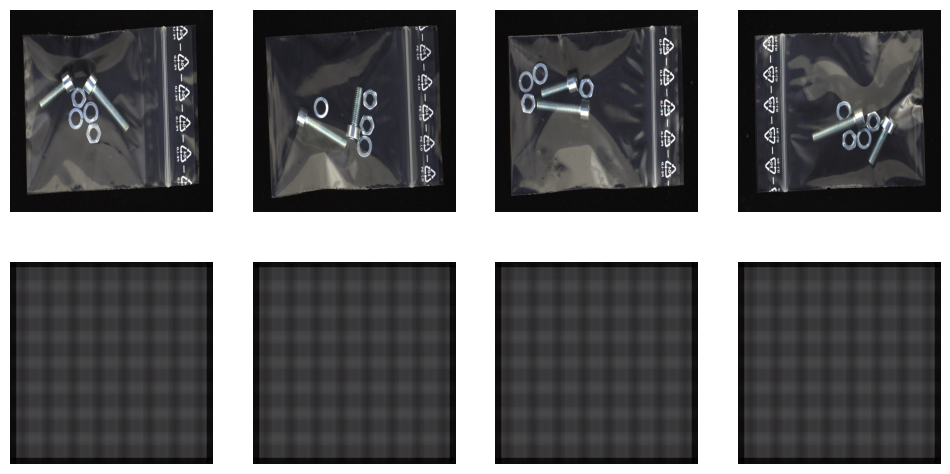

/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training
Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 6/500, Train Loss: 0.098796, Test AUROC: 0.4745


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 7/500, Train Loss: 0.098566, Test AUROC: 0.4768


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 8/500, Train Loss: 0.098346, Test AUROC: 0.4747


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 9/500, Train Loss: 0.098261, Test AUROC: 0.4734


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 10/500, Train Loss: 0.098077, Test AUROC: 0.4748


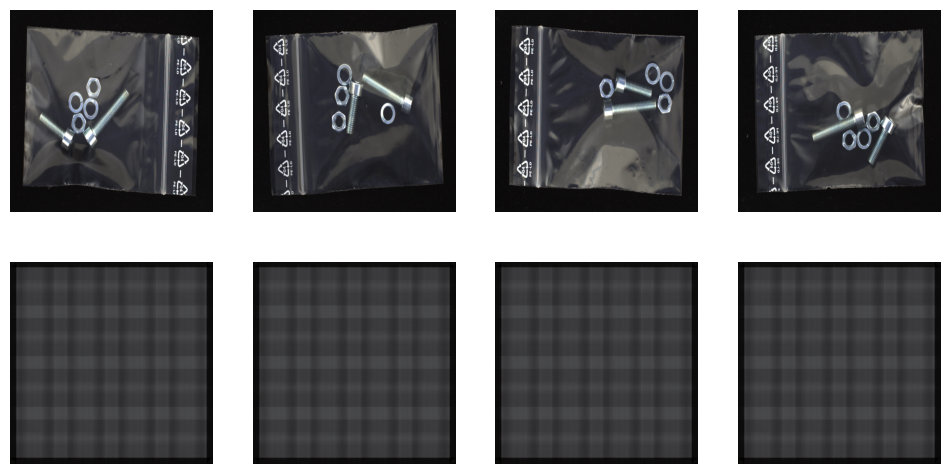

/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training
Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 11/500, Train Loss: 0.098052, Test AUROC: 0.4748


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 12/500, Train Loss: 0.098038, Test AUROC: 0.4685


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 13/500, Train Loss: 0.098095, Test AUROC: 0.4688


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 14/500, Train Loss: 0.097962, Test AUROC: 0.4730


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 15/500, Train Loss: 0.097953, Test AUROC: 0.4741


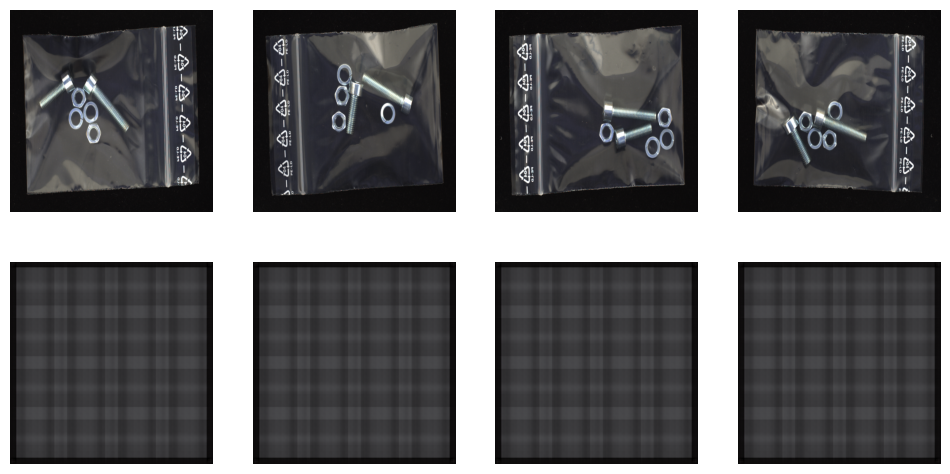

/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training
Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 16/500, Train Loss: 0.097979, Test AUROC: 0.4735


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 17/500, Train Loss: 0.097978, Test AUROC: 0.4722


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 18/500, Train Loss: 0.097949, Test AUROC: 0.4721


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 19/500, Train Loss: 0.098043, Test AUROC: 0.4718


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 20/500, Train Loss: 0.097970, Test AUROC: 0.4749


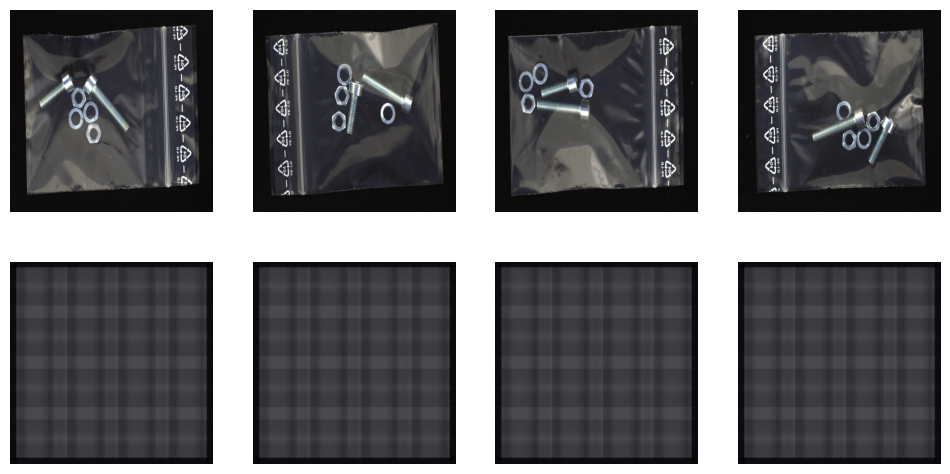

/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training
Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_574606/3112498311.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed precision training


Epoch 21/500, Train Loss: 0.097935, Test AUROC: 0.4673


Training:   0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_574606/3112498311.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


KeyboardInterrupt: 

In [12]:
# Main Function
def main():
    # Hyperparameters
    img_size = 1024
    patch_size = 32
    num_channels = 3
    filters = 256  # Increased to handle dimension reductions
    transformer_layers = 8
    num_heads = 8
    batch_size = 8
    num_epochs = 500
    learning_rate = 1e-4
    ROOT_DIR = "/home/hafiz/my_thesis/seg_recons/dataset/screw_bag"  # Update this path
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])

    # Datasets and Dataloaders
    train_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='train', transform=transform)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    test_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='test', transform=transform)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model, Loss, Optimizer
    model = TAE(
        image_size=img_size,
        patch_size=patch_size,
        num_channels=num_channels,
        filters=filters,
        transformer_layers=transformer_layers,
        num_heads=num_heads,
        rate=0.0
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # Load the saved model and optimizer states (if any)
    checkpoint_path = 'checkpoint.pth'  # Update this path
    if os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from '{checkpoint_path}'")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        # Load model state
        model.load_state_dict(checkpoint['model_state_dict'])
        # Load optimizer state
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        # Set the starting epoch to the saved epoch
        start_epoch = checkpoint['epoch'] + 1  # Continue training from the next epoch
        print(f"Resuming training from epoch {start_epoch}.")
    else:
        print(f"No checkpoint found at '{checkpoint_path}'")
        start_epoch = 0  # If no checkpoint is found, start from epoch 0

    # Training Loop
    for epoch in range(start_epoch, start_epoch + num_epochs):
        train_loss = train(model, train_loader, optimizer, criterion, device)
        auroc = evaluate(model, test_loader, device)

        print(
            f"Epoch {epoch+1}/{start_epoch + num_epochs}, "
            f"Train Loss: {train_loss:.6f}, "
            f"Test AUROC: {auroc:.4f}"
        )
        if (epoch + 1) % 5 == 0:
            visualize_reconstruction(model, test_loader, device)
        if (epoch + 1) % 25 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, f'H_TAE_checkpoint_epoch_{epoch+1}.pth')

    # Save the model after training
    torch.save(model.state_dict(), f'H_TAE_epoch_{epoch+1}.pth')
    torch.save(optimizer.state_dict(), f'H_TAE_optim_epoch_{epoch+1}.pth')

if __name__ == "__main__":
    main()